[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Bluerrror/germany-hydrology/blob/main/examples/basin_explorer.ipynb)

# 🗺️ Basin explorer — pick a basin, get its data

**Click a catchment on the map** (or pick a river gauge from the dropdown),
choose which source to use for each domain —

| domain | options |
|--------|---------|
| Climate | ERA5 (basin centroid) · DWD station (nearest) · HYRAS 1 km grid |
| Land cover | ESA WorldCover 2021 / 2020 |
| Soil | BÜK1000 polygons · SoilGrids (clay, sand, pH, SOC) |
| Hydrology | PEGELONLINE water level / discharge |
| Terrain | Copernicus DEM 90 m / 30 m |

— then press **Fetch basin data**. Everything lands in the `basin_data`
dict, ready for modelling; previews are drawn in the tabs below the map.

Needs a live kernel; on GitHub only the static demo at the bottom shows
output.

In [1]:
# Setup — no-op locally; on Colab installs both plugins and enables widgets
import importlib.util, sys

if importlib.util.find_spec("germany_hydrology") is None:
    %pip install -q git+https://github.com/Bluerrror/germany-hydrology ipyleaflet ipywidgets
if importlib.util.find_spec("earthkit_data_soilgrids") is None:
    %pip install -q git+https://github.com/Bluerrror/earthkit-data-soilgrids
if "google.colab" in sys.modules:
    from google.colab import output
    output.enable_custom_widget_manager()

In [2]:
import json

import earthkit.data as ekd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ekd.config.set("cache-policy", "user")

from germany_hydrology import GERMANY
from germany_hydrology.landcover import CLASSES

# selection layers: catchments (HydroBASINS level 7) and river gauges
basins = ekd.from_source("hydrosheds", product="basins", level=7, bbox=GERMANY).to_pandas()
gauges = ekd.from_source("pegelonline").to_pandas().dropna(subset=["longitude", "latitude"])
print(f"{len(basins)} basins, {len(gauges)} gauges loaded")

252 basins, 729 gauges loaded


## Fetch helpers

One plain function per domain — the widget UI below just dispatches to
these, so you can call them directly in your own scripts too.

In [3]:
def fetch_climate(source, basin, start="2015-01-01", end="2023-12-31", hyras_year=2020):
    lon, lat = basin.geometry.centroid.x, basin.geometry.centroid.y
    if source == "ERA5 (centroid)":
        return ekd.from_source(
            "era5-timeseries", latitude=lat, longitude=lon, start=start, end=end,
            variables=["precipitation_sum", "temperature_2m_mean",
                       "et0_fao_evapotranspiration"],
        ).to_pandas()
    if source == "DWD station (nearest)":
        st = ekd.from_source("dwd-observations").to_pandas()
        st = st[st["to_date"] > "2020"]
        d2 = (st["latitude"] - lat) ** 2 + (st["longitude"] - lon) ** 2
        sid = d2.idxmin()
        df = ekd.from_source("dwd-observations", station=sid, period="all").to_pandas()
        df.attrs["station"] = f"{st.loc[sid, 'name']} ({sid})"
        return df
    if source == "HYRAS grid (1 km)":
        w, s, e, n = basin.geometry.bounds
        return ekd.from_source("dwd-grids", variable="precipitation",
                               years=hyras_year, bbox=[w, s, e, n]).to_xarray()
    raise ValueError(source)


def fetch_landcover(source, basin):
    year = int(source.split()[-1])
    w, s, e, n = basin.geometry.bounds
    da = ekd.from_source("worldcover", bbox=[w, s, e, n], year=year).to_xarray()
    da = da.rio.clip([basin.geometry], crs="EPSG:4326", drop=True)
    counts = pd.Series(da.values.ravel()).dropna().value_counts(normalize=True)
    fractions = (counts.rename(index=CLASSES) * 100).round(2)
    return da, fractions


def fetch_soil(source, basin):
    w, s, e, n = basin.geometry.bounds
    if source == "BÜK1000 (polygons)":
        import geopandas as gpd
        gdf = ekd.from_source("buek1000", bbox=[w, s, e, n]).to_pandas()
        return gdf.clip(basin.geometry)
    prop = {"SoilGrids clay": "clay", "SoilGrids sand": "sand",
            "SoilGrids pH": "phh2o", "SoilGrids SOC": "soc"}[source]
    da = ekd.from_source("soilgrids", property=prop, depth="0-5cm",
                         stat="mean", bbox=[w, s, e, n]).to_xarray()["band_1"]
    return (da.where(da != 0) / 10.0).rename(prop)


def fetch_hydrology(source, gauge_name):
    if gauge_name is None:
        raise ValueError("No gauge inside/near this basin — pick one on the map.")
    parameter = "W" if "level" in source else "Q"
    return ekd.from_source("pegelonline", station=gauge_name,
                           parameter=parameter, start="P30D").to_pandas()


def fetch_terrain(source, basin):
    res = 90 if "90" in source else 30
    w, s, e, n = basin.geometry.bounds
    da = ekd.from_source("copernicus-dem", bbox=[w, s, e, n], resolution=res).to_xarray()
    return da.rio.clip([basin.geometry], crs="EPSG:4326", drop=True)

## The interactive explorer

Click a basin → it highlights, and the gauge dropdown narrows to gauges
inside it. Choose sources, tick the domains you want, press **Fetch**.

In [4]:
import ipywidgets as W
from ipyleaflet import GeoJSON, Map, WidgetControl, basemaps

m = Map(center=(51.2, 10.3), zoom=6, basemap=basemaps.OpenStreetMap.Mapnik,
        scroll_wheel_zoom=True, layout=W.Layout(height="480px"))

basin_layer = GeoJSON(
    data=json.loads(basins.to_json()),
    style={"color": "#31688e", "weight": 1, "fillOpacity": 0.05},
    hover_style={"fillOpacity": 0.25},
)
m.add(basin_layer)
highlight = GeoJSON(data={"type": "FeatureCollection", "features": []},
                    style={"color": "#d95f02", "weight": 3, "fillOpacity": 0.15})
m.add(highlight)

state = {"basin": None, "gauge": None}

climate_dd = W.Dropdown(options=["ERA5 (centroid)", "DWD station (nearest)",
                                 "HYRAS grid (1 km)"], description="Climate")
lc_dd = W.Dropdown(options=["WorldCover 2021", "WorldCover 2020"], description="Land cover")
soil_dd = W.Dropdown(options=["BÜK1000 (polygons)", "SoilGrids clay", "SoilGrids sand",
                              "SoilGrids pH", "SoilGrids SOC"], description="Soil")
hydro_dd = W.Dropdown(options=["Water level (W)", "Discharge (Q)"], description="Hydrology")
terrain_dd = W.Dropdown(options=["DEM 90 m", "DEM 30 m"], description="Terrain")
gauge_dd = W.Dropdown(options=sorted(gauges.index), description="Gauge")
domains = {name: W.Checkbox(value=name in ("climate", "landcover"), description=name,
                            indent=False, layout=W.Layout(width="110px"))
           for name in ("climate", "landcover", "soil", "hydrology", "terrain")}
fetch_btn = W.Button(description="Fetch basin data", button_style="primary", icon="download")
status = W.HTML("<i>Click a basin on the map, or pick a gauge.</i>")

tabs = W.Tab()
outputs = {name: W.Output() for name in domains}
tabs.children = list(outputs.values())
for i, name in enumerate(outputs):
    tabs.set_title(i, name)

basin_data = {}


def _select_basin(hybas_id):
    row = basins[basins["HYBAS_ID"] == hybas_id].iloc[0]
    state["basin"] = row
    highlight.data = json.loads(basins[basins["HYBAS_ID"] == hybas_id].to_json())
    w, s, e, n = row.geometry.bounds
    inside = gauges[gauges["longitude"].between(w, e) & gauges["latitude"].between(s, n)]
    gauge_dd.options = sorted(inside.index) or sorted(gauges.index)
    state["gauge"] = gauge_dd.options[0] if len(inside) else None
    status.value = (f"Basin <b>{hybas_id}</b> selected "
                    f"({row.geometry.area * 111**2 * np.cos(np.radians(s)):,.0f} km² approx, "
                    f"{len(inside)} gauges inside).")


def on_basin_click(event=None, feature=None, **kwargs):
    if feature:
        _select_basin(feature["properties"]["HYBAS_ID"])

basin_layer.on_click(on_basin_click)


def on_gauge_change(change):
    if change["new"] is None:
        return
    state["gauge"] = change["new"]
    g = gauges.loc[change["new"]]
    hit = basins[basins.contains(__import__("shapely").geometry.Point(g["longitude"], g["latitude"]))]
    if len(hit):
        _select_basin(hit["HYBAS_ID"].iloc[0])
    m.center = (float(g["latitude"]), float(g["longitude"]))
    m.zoom = 9

gauge_dd.observe(on_gauge_change, names="value")


FETCHERS = {
    "climate":   lambda b: fetch_climate(climate_dd.value, b),
    "landcover": lambda b: fetch_landcover(lc_dd.value, b),
    "soil":      lambda b: fetch_soil(soil_dd.value, b),
    "hydrology": lambda b: fetch_hydrology(hydro_dd.value, state["gauge"]),
    "terrain":   lambda b: fetch_terrain(terrain_dd.value, b),
}


def _preview(name, result):
    out = outputs[name]
    out.clear_output()
    with out:
        fig, ax = plt.subplots(figsize=(7, 3))
        if name == "climate":
            if hasattr(result, "data_vars"):          # HYRAS Dataset
                result["pr"].mean("time").plot(ax=ax)
                ax.set_title("HYRAS mean daily precipitation")
            else:
                col = "precipitation_sum" if "precipitation_sum" in result else "RSK"
                result[col].resample("MS").sum().plot(ax=ax, color="#31688e")
                ax.set_title(f"monthly precipitation — {result.attrs.get('station', 'ERA5')}")
        elif name == "landcover":
            result[1].plot.barh(ax=ax, color="#31688e")
            ax.set_xlabel("% of basin area"); ax.set_title(lc_dd.value)
        elif name == "soil":
            if hasattr(result, "geometry"):
                result.plot(ax=ax, column="Symbol", cmap="tab20", edgecolor="white", lw=0.2)
                ax.set_title("BÜK1000 soil units")
            else:
                result.plot(ax=ax); ax.set_title(soil_dd.value + " (0–5 cm)")
        elif name == "hydrology":
            result.iloc[:, 0].plot(ax=ax, color="#31688e")
            ax.set_title(f"{state['gauge']} — {result.columns[0]}")
        elif name == "terrain":
            result.plot(ax=ax, cmap="terrain")
            ax.set_title(terrain_dd.value)
        plt.tight_layout(); plt.show()


def on_fetch(_):
    if state["basin"] is None:
        status.value = "<b style='color:#b00'>Select a basin first.</b>"
        return
    for name, box in domains.items():
        if not box.value:
            continue
        status.value = f"Fetching <b>{name}</b> …"
        try:
            basin_data[name] = FETCHERS[name](state["basin"])
            _preview(name, basin_data[name])
        except Exception as exc:
            with outputs[name]:
                outputs[name].clear_output()
                print(f"{name} failed: {exc}")
    basin_data["basin"] = state["basin"]
    status.value = f"Done — basin_data has: <b>{sorted(basin_data)}</b>"

fetch_btn.on_click(on_fetch)

ui = W.VBox([
    W.HBox([climate_dd, lc_dd, soil_dd]),
    W.HBox([hydro_dd, terrain_dd, gauge_dd]),
    W.HBox(list(domains.values()) + [fetch_btn]),
    status, m, tabs,
])
ui

(interactive widget — run the notebook to use it)

After fetching, everything is in plain Python objects:

```python
basin_data["climate"]     # DataFrame (ERA5/DWD) or xarray Dataset (HYRAS)
basin_data["landcover"]   # (DataArray, class-fraction Series)
basin_data["soil"]        # GeoDataFrame (BÜK) or DataArray (SoilGrids)
basin_data["hydrology"]   # DataFrame of gauge measurements
basin_data["terrain"]     # elevation DataArray
basin_data["basin"]       # the selected HydroBASINS row
```

## Static demo (no widgets — runs anywhere)

The same helpers, driven programmatically for the basin containing the
Hann. Münden gauge:

(interactive widget — run the notebook to use it)

(interactive widget — run the notebook to use it)

(interactive widget — run the notebook to use it)

(interactive widget — run the notebook to use it)

(interactive widget — run the notebook to use it)

(interactive widget — run the notebook to use it)

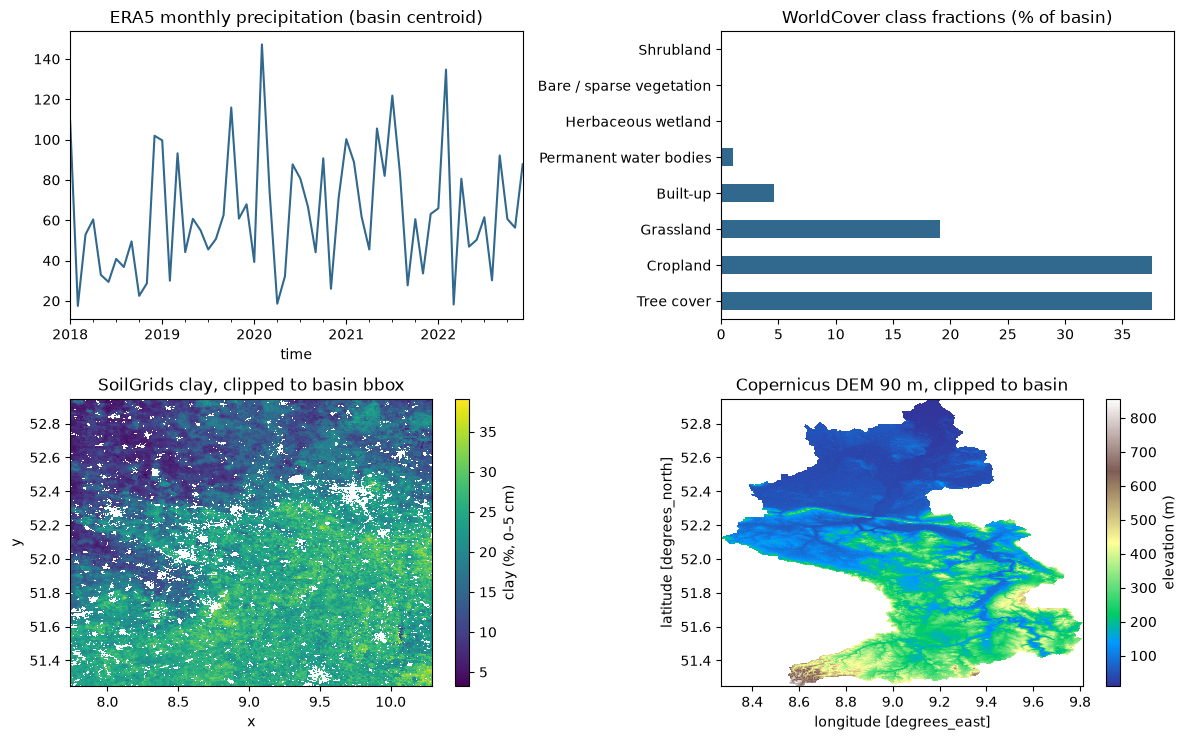

water level range last 30 days: 114.0 - 145.0 cm


In [5]:
from shapely.geometry import Point

g = gauges.loc["HANN.MUENDEN"]
basin = basins[basins.contains(Point(g["longitude"], g["latitude"]))].iloc[0]

climate = fetch_climate("ERA5 (centroid)", basin, start="2018-01-01", end="2022-12-31")
lc_da, lc_frac = fetch_landcover("WorldCover 2021", basin)
soil = fetch_soil("SoilGrids clay", basin)
hydro = fetch_hydrology("Water level (W)", "HANN.MUENDEN")
dem = fetch_terrain("DEM 90 m", basin)

fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
climate["precipitation_sum"].resample("MS").sum().plot(ax=axes[0, 0], color="#31688e")
axes[0, 0].set_title("ERA5 monthly precipitation (basin centroid)")
lc_frac.plot.barh(ax=axes[0, 1], color="#31688e")
axes[0, 1].set_title("WorldCover class fractions (% of basin)")
soil.plot(ax=axes[1, 0], cmap="viridis", cbar_kwargs={"label": "clay (%, 0–5 cm)"})
axes[1, 0].set_title("SoilGrids clay, clipped to basin bbox")
dem.plot(ax=axes[1, 1], cmap="terrain", cbar_kwargs={"label": "elevation (m)"})
axes[1, 1].set_title("Copernicus DEM 90 m, clipped to basin")
plt.tight_layout(); plt.show()

print("water level range last 30 days:",
      float(hydro.iloc[:, 0].min()), "-", float(hydro.iloc[:, 0].max()), "cm")

Data: DWD (CC-BY 4.0) · WSV PEGELONLINE · HydroSHEDS · BGR BÜK1000 ·
ISRIC SoilGrids (CC-BY 4.0) · ESA WorldCover (CC-BY 4.0) · Copernicus
DEM © DLR/Airbus/ESA · ERA5 via Open-Meteo (CC-BY 4.0).